# Fitting PPV with JAX/Optax
In this example we   
- generate two PPV cubes for p-NH2D and N2D+ starting from aribrary parameters (infall+rotation)    
- optimize the model starting from another set of initial parameters    
- do some anlysis   

In [ ]:
import matplotlib.pyplot as plt
import jax.numpy as jnp
import numpy as np
from spectra import get_lines
from model import get_ppvs, df_dparam
from optimizer import optimize
from plots import plot_channels, plot_spectra, plot_slice, plot_comparison, plot_profiles
from tqdm import tqdm

## Part 1: Target model and PPVs generation

In [ ]:
# change this parameters depending on your GPU capabilities
loss_target = 1e-6  # target loss for optimization stopping criterion (1e-6 is usually good)
number_of_velocity_channels = 128 # number of velocity channels in the synthetic spectra (128 is usually good)

# velocity channels range ([-5, 5] covers most of the spectral features, but [-2, 2] works fine in this example)
velocity_channel_min = -2.0  # km/s
velocity_channel_max = 2.0  # km/s

### Load spectroscopic data
Load spectroscopic data from a PySpecKit model file for p-NH2D and N2D+.

In [ ]:
# define molecules to analyze
molecules = ["p-NH2D", "N2D+"]

# load line data for each molecule
vprof_neutral, Iprof_neutral, freq0_neutral = get_lines(molecules[0])
vprof_ion, Iprof_ion, freq0_ion = get_lines(molecules[1])

# define velocity channels for spectra
vchans = jnp.linspace(velocity_channel_min, velocity_channel_max, number_of_velocity_channels)

print("Spectral resolution (m/s): ", (vchans[1] - vchans[0])*1e3)


Spectral resolution (m/s):  31.496048


### Set the target parameters 
Define some target parameters, see comments for details.
This is an infall with rotation and an emitting gas "donut" at r=0.5.      
No asymmetries, the object has some rotation on the three angles (yaw, pitch, roll).  

In [ ]:
# Where two values are given, the first is for the neutral species, the second for the ionized species
target_params = {
    'mff': 0.5,  # <<< Infall component
    'mrot': -0.5, # <<< Rotation component
    'xoffset': jnp.array([0e0, 0e0]), # <<< Spatial offset in x (plane of sky)
    'zoffset': jnp.array([0e0, 0e0]), # <<< Spatial offset in z (plane of sky)
    'vbulk': 0.1, # <<< Bulk velocity shift

    'v0': jnp.array([1e-3, 2e-3]), # <<< Velocity scaling of the Gaussian profile
    'r0_v': np.array([0.5, 0.7]), # <<< Center of the Gaussian velocity profile [0, 1]
    'sigma_v': jnp.array([0.1, 0.1]), # <<< Width of the Gaussian velocity profile

    'ngas0': jnp.array([1.0, 0.8]), # <<< Gas density scaling of the Gaussian profile
    'r0_ngas': jnp.array([0.5, 0.5]), # <<< Center of the Gaussian gas density profile [0, 1]
    'sigma_ngas': jnp.array([0.3, 0.2]), # <<< Width of the Gaussian gas density profile

    'sigma_turb': jnp.array([0.05, 0.08]), # <<< Microturbulent broadening
    'sigmadx': jnp.log10(jnp.array([0.05, 0.01])), # <<< Absorption coefficient scaling

    'theta0': jnp.pi/8., # <<< Yaw angle
    'theta1': jnp.pi*2./3., # <<< Pitch angle
    'theta2': jnp.pi/4., # <<< Roll angle
    'zratio': 0.7, # <<< Flattening of the core along the z axis

    'asym': jnp.array([0e0, 0e0]), # <<< Asymmetry scaling
    'asym_theta': jnp.array([0e0, 0e0]) # <<< Asymmetry angle
}

# bundle model arguments (spectral data)
model_args = {
    'Iprof': [Iprof_neutral, Iprof_ion],
    'vprof': [vprof_neutral, vprof_ion],
    'vchans': vchans
}

### Generate target model
Generate the target PPV cubes for p-NH2D and N2D+ using the target parameters defined above.     

In [ ]:
# return the target PPV cubes and models for both species
ppvs_target, _, _, models_target = get_ppvs(target_params, model_args)

### Show velocity and density profiles along x, y, and z
Show the velocity and density profiles along the central lines of the cube for both species.   
The second panel are the profiles on the LOS (y) for the central pixel (x=0, z=0).

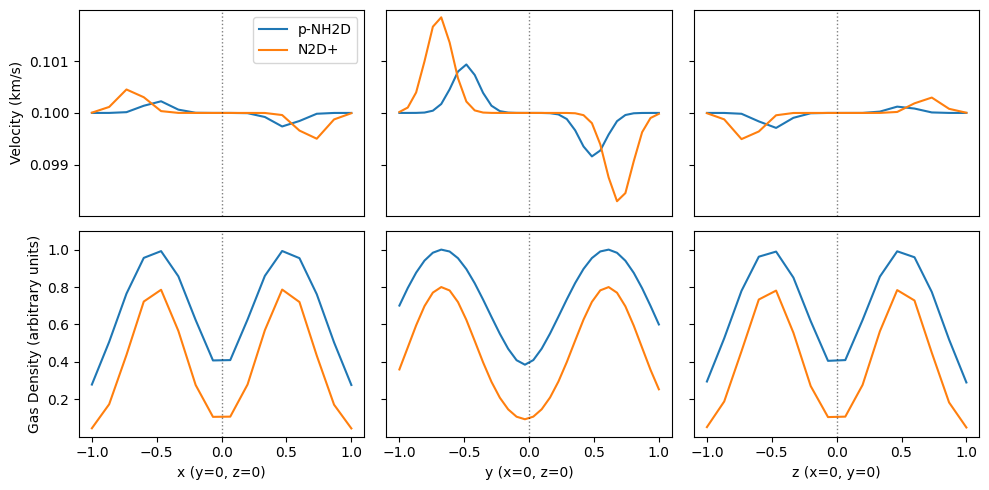

In [ ]:
plot_profiles(models_target, molecules)


### Plot maps of velocity channels around maximum intensity (bracketing of PPV along V)
Select some velocity channels around the maximum intensity channel and plot the maps for both species.    
The colorscale is the same for both species and normalized to the global maximum intensity.

Velocity channel max 0.23622036 km/s
Plotting 50 channels out of 128 in [-0.55-0.24] km/s


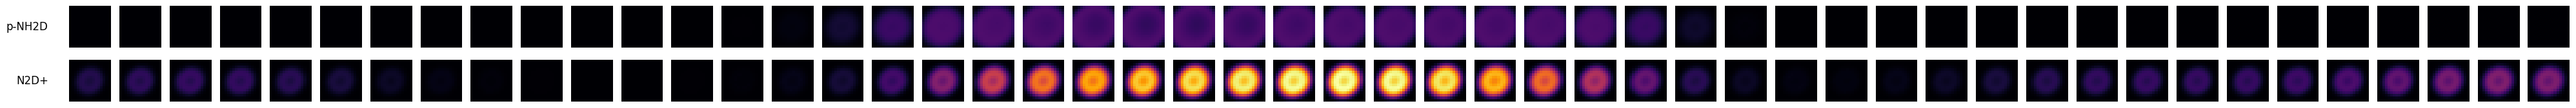

In [ ]:
# nchans channels to plot around the maximum intensity channel
plot_channels(ppvs_target, vchans, molecules, nchans=50)

### Plot spectrum of the central pixel
Plot the spectrum of the central pixel (x=0, z=0) for both species.

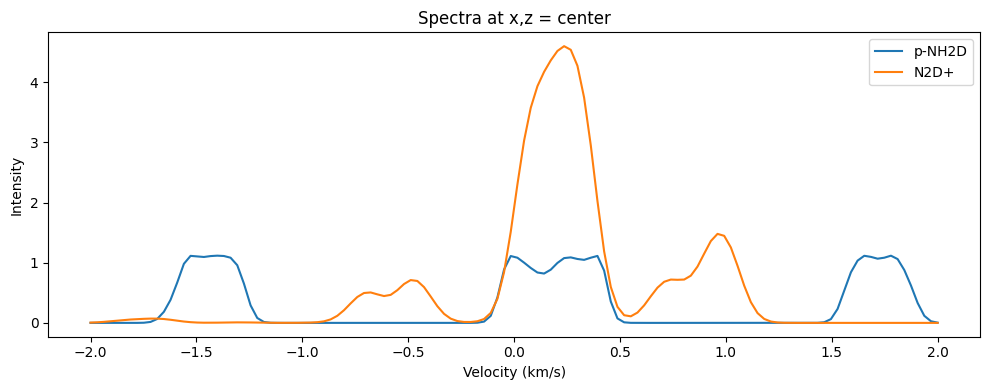

In [ ]:
plot_spectra(ppvs_target, vchans, molecules)

### Velocity and density cut at z=0 and x=0
Cut at z=0 plane (i.e., the horizontal plane wrt the observer) of velocity (both species) and density (p-NH2D only).    
The dashed line is the LOS.    

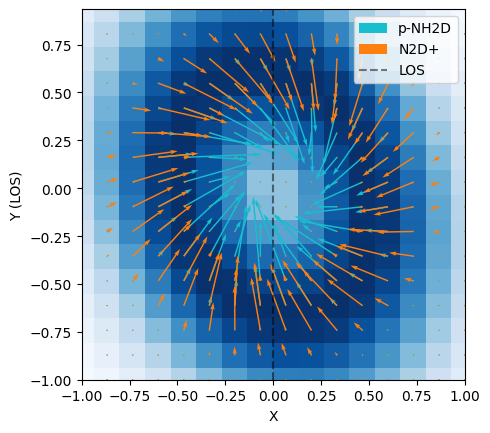

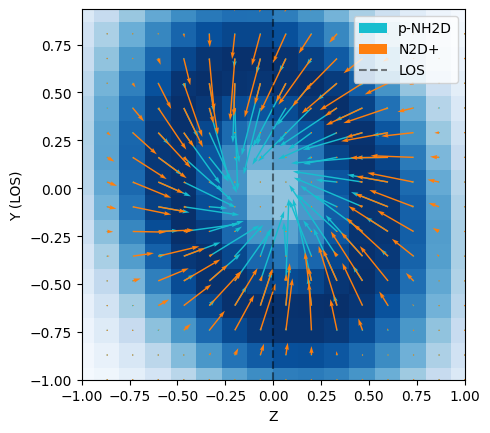

In [ ]:
plot_slice(models_target, molecules, slice='xy')
plot_slice(models_target, molecules, slice='zy')


## Part 2: Optimization

### Set initial parameters for optimization
Set some initial guess parameters for the optimization.     

In [ ]:
init_params  = {
    'mff': 0.1,  # <<< Infall component
    'mrot': 0.1, # <<< Rotation component
    'xoffset': jnp.array([0e0, 0e0]), # <<< Spatial offset in x (plane of sky)
    'zoffset': jnp.array([0e0, 0e0]), # <<< Spatial offset in z (plane of sky)
    'vbulk': 0e0, # <<< Bulk velocity shift

    'v0': jnp.array([1e-4, 1e-4]), # <<< Velocity scaling of the Gaussian profile
    'r0_v': np.array([0.5, 0.5]), # <<< Center of the Gaussian velocity profile [0, 1]
    'sigma_v': jnp.array([0.05, 0.05]), # <<< Width of the Gaussian velocity profile

    'ngas0': jnp.array([1e0, 1e0]), # <<< Gas density scaling of the Gaussian profile
    'r0_ngas': jnp.array([0.1, 0.1]), # <<< Center of the Gaussian gas density profile [0, 1]
    'sigma_ngas': jnp.array([0.1, 0.1]), # <<< Width of the Gaussian gas density profile

    'sigma_turb': jnp.array([0.01, 0.01]), # <<< Microturbulent broadening
    'sigmadx': jnp.log10(jnp.array([0.1, 0.01])), # <<< Absorption coefficient scaling

    'theta0': 0e0, # <<< Yaw angle
    'theta1': 0e0, # <<< Pitch angle
    'theta2': 0e0, # <<< Roll angle
    'zratio': 1e0, # <<< Flattening of the core along the z axis

    'asym': jnp.array([0e0, 0e0]), # <<< Asymmetry scaling
    'asym_theta': jnp.array([0e0, 0e0]) # <<< Asymmetry angle
}


### Plot initial guess for the central pixel spectrum
Compare the initial guess model with the target for the central pixel spectrum to show how off is the initial guess.    

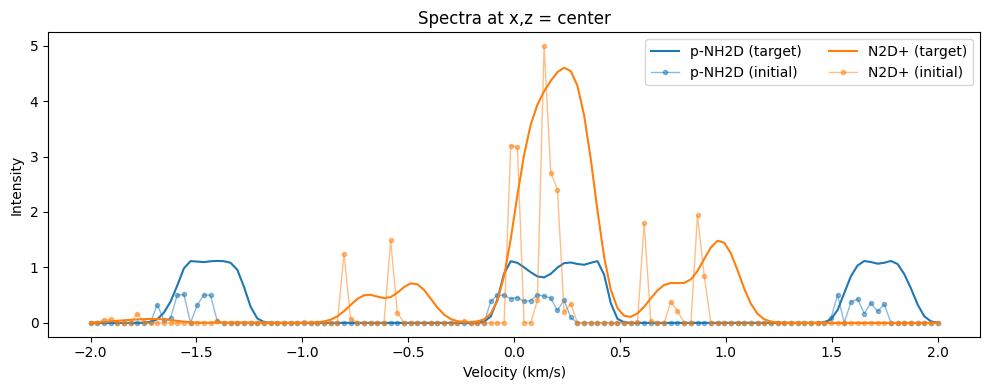

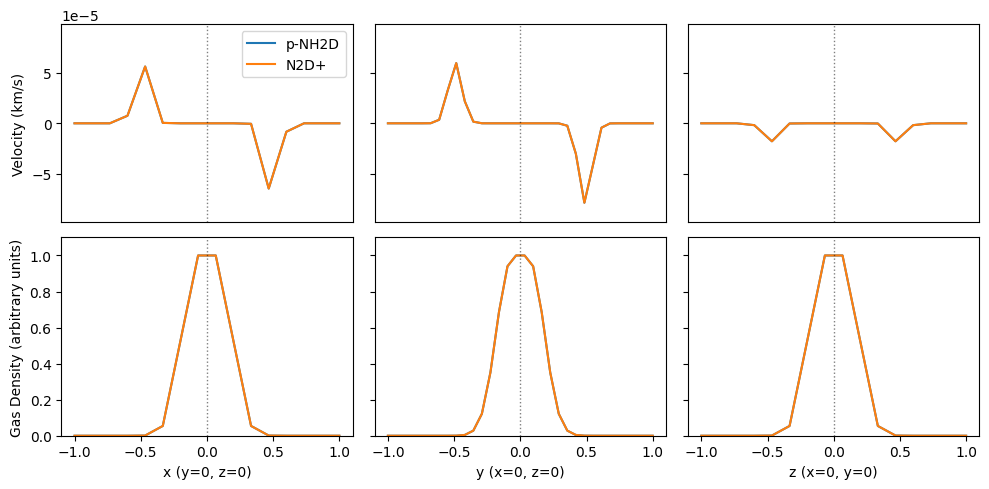

Velocity channel max 0.14173222
Max difference: 1.0271322


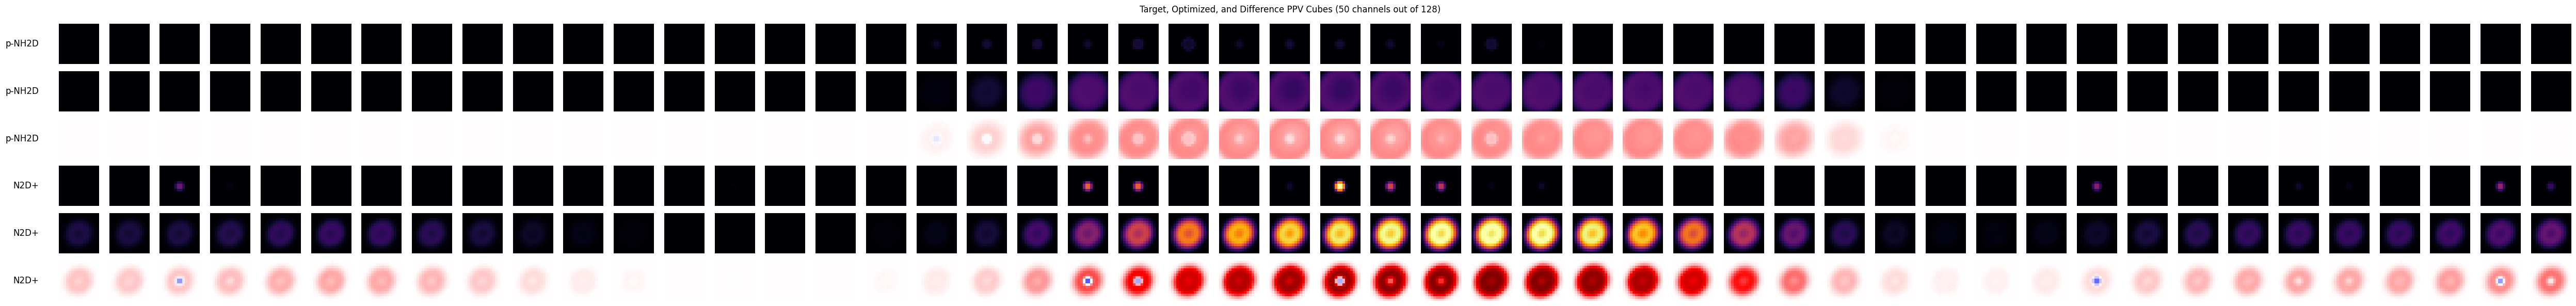

In [ ]:
# generate the model PPV cubes for the initial guess parameters
ppvs_init, _, _, models_init = get_ppvs(init_params, model_args)

# compare spectra
plot_spectra(ppvs_target, vchans, molecules, ppvs_init, labels=['target', 'initial'])

# compare profiles
plot_profiles(models_init, molecules)

# compare channel maps
plot_comparison(ppvs_init, ppvs_target, vchans, molecules, nchans=50)

### Optimize
Optimize the model parameters using JAX/Optax to minimize the difference between the model and target PPV cubes.

In [ ]:
params_history = {k: [v] for k, v in init_params.items()}

print("It takes a while to compile before starting optimization because JAX needs to compile the functions...")
optimized_params, ppvs_optimized, ems, optimized_models, params_history, loss_history = optimize(init_params, ppvs_target, model_args,
                                                                                         learning_rate=1e-4, params_history=params_history,
                                                                                         loss_target=loss_target)


It takes a while to compile before starting optimization because JAX needs to compile the functions...


Loss: 1.027025e-06, Target: 1.000000e-06, Epoch: 19420: 100%|██████████| 100/100 [03:02<00:00,  1.83s/it]      


Converged at step 19427, Loss: 9.991244e-07 < 1.000000e-06


### Plot Loss

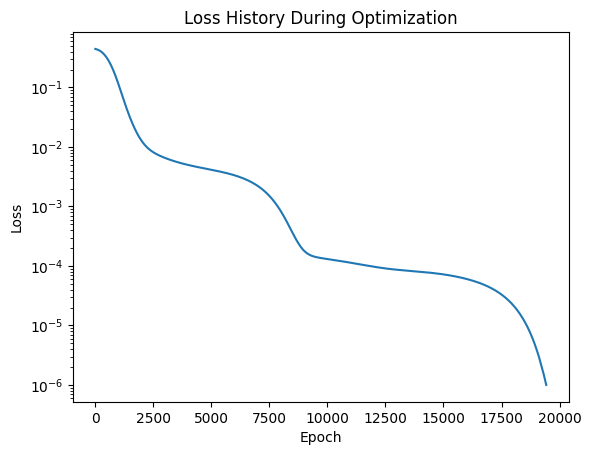

In [ ]:
plt.plot(loss_history)
plt.yscale('log')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss History During Optimization")
plt.show()

### Plot maps of target, optimized, and their difference for both molecules (PPV bracketing along V)

Velocity channel max 0.23622036
Max difference: 0.00263797


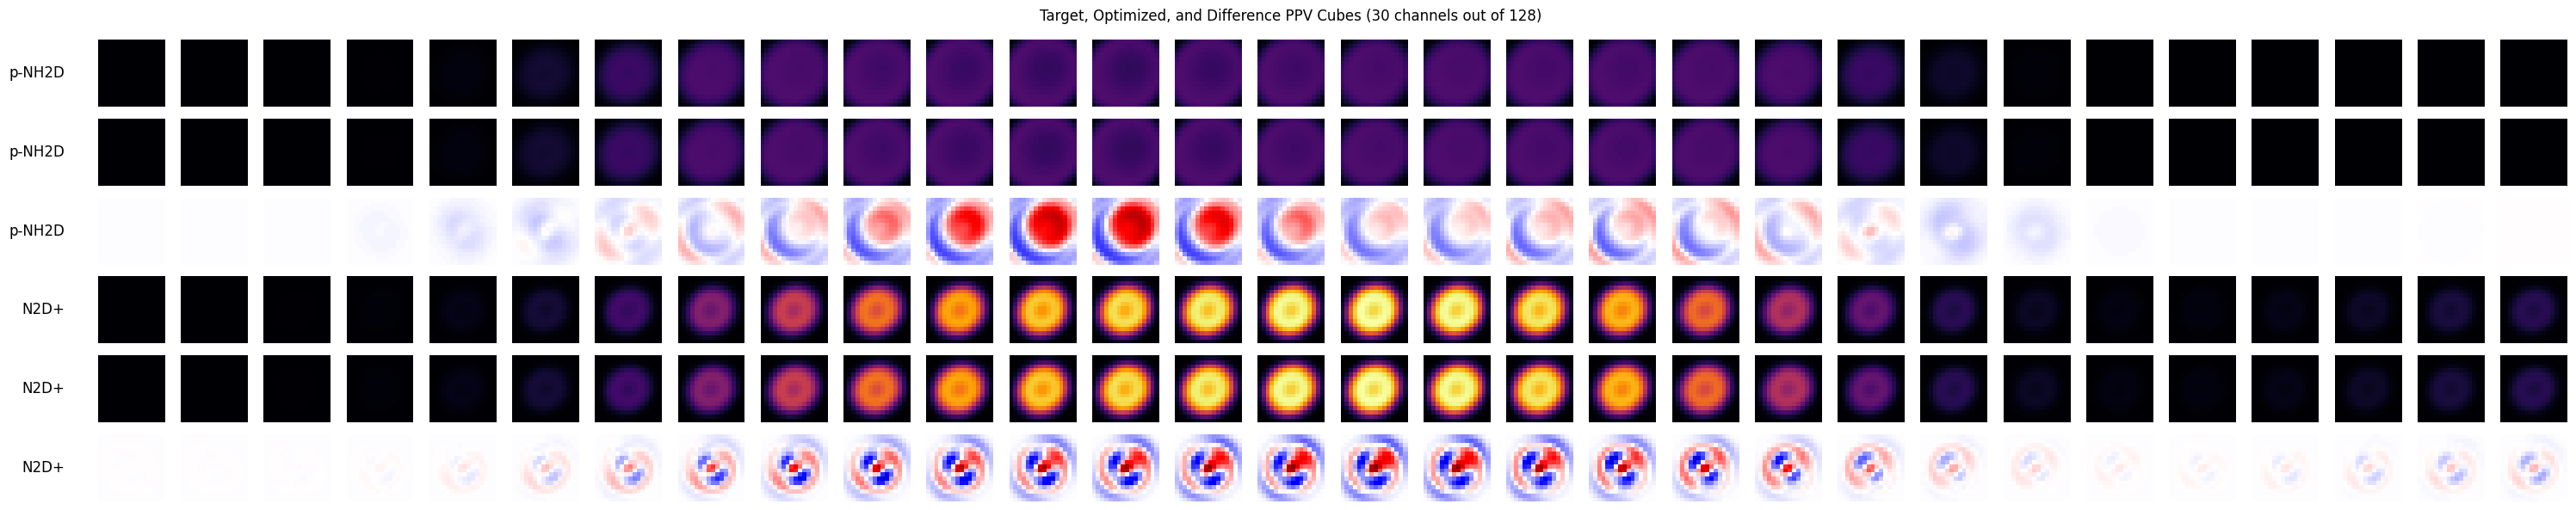

In [ ]:
plot_comparison(ppvs_target, ppvs_optimized, vchans, molecules, nchans=30)


### Plot spectra in the central pixel (target vs optimized)

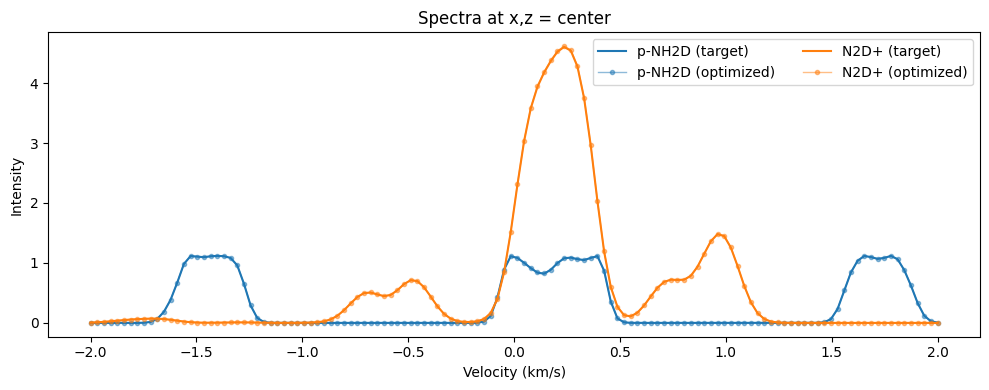

In [ ]:
plot_spectra(ppvs_target, vchans, molecules, ppvs_optimized, fname='optimized_spectra.pdf', labels=['target', 'optimized'])

### Plot velocity field and density after optimization for a slice at z=0

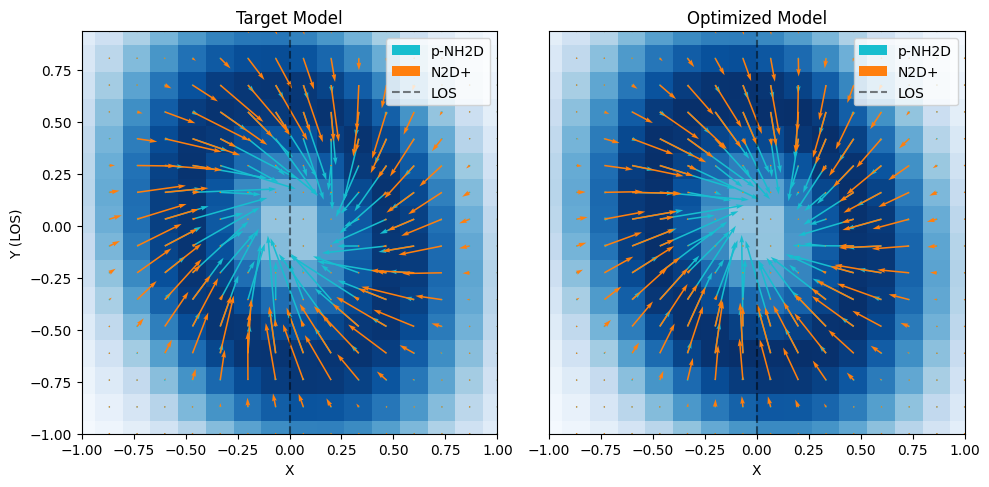

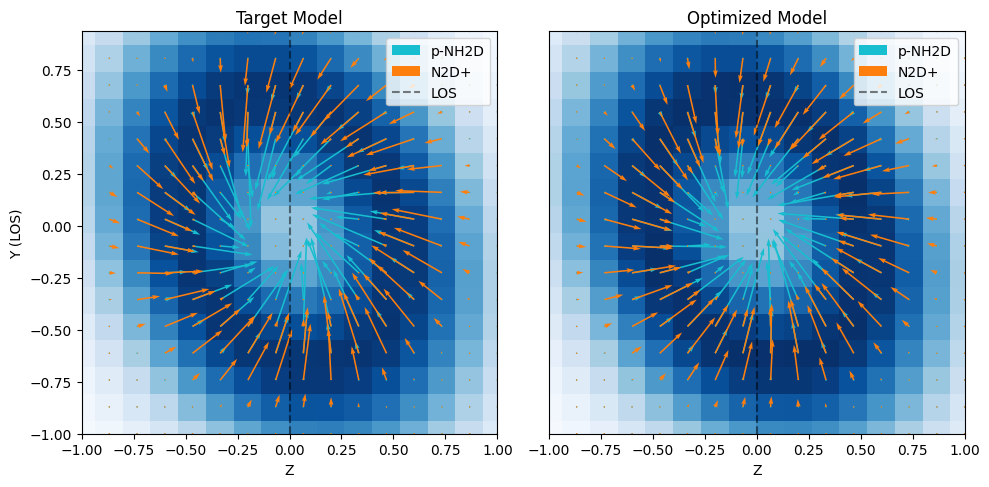

In [ ]:
plot_slice([models_target, optimized_models], molecules, titles=["Target Model", "Optimized Model"], fname="slice_comparison_xy.pdf", slice='xy')
plot_slice([models_target, optimized_models], molecules, titles=["Target Model", "Optimized Model"], fname="slice_comparison_zy.pdf", slice='zy')

### Plot optimzed profiles along x, y, and z

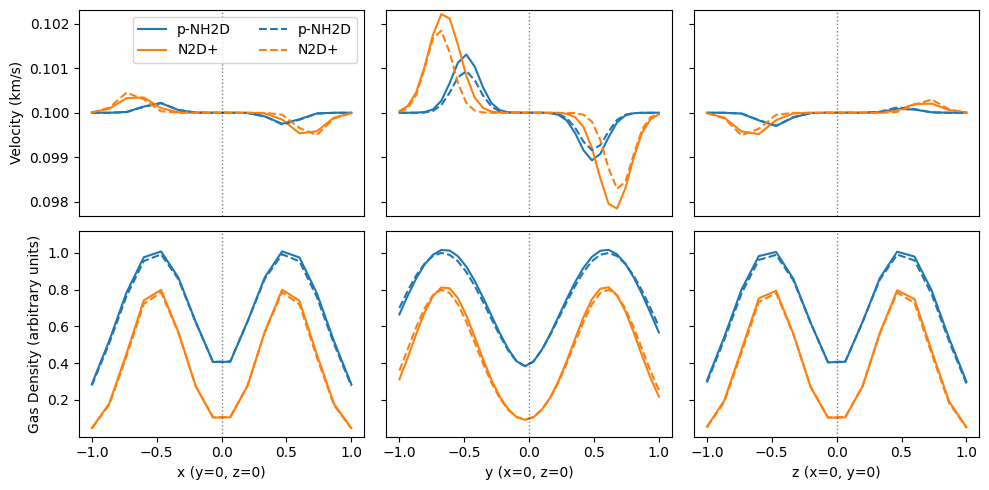

In [ ]:
plot_profiles([optimized_models, models_target], molecules)

## Part 3: Derivatives and parameter analysis

### Compute numerical derivatives of the PPV cubes with respect to each parameter
Compute numerical derivatives of the PPV cubes with respect to each parameter by finite differences.  
The results are shown for the central pixel (x=0, z=0) and for the corresponding velocity channels.  

100%|██████████| 19/19 [00:27<00:00,  1.45s/it]


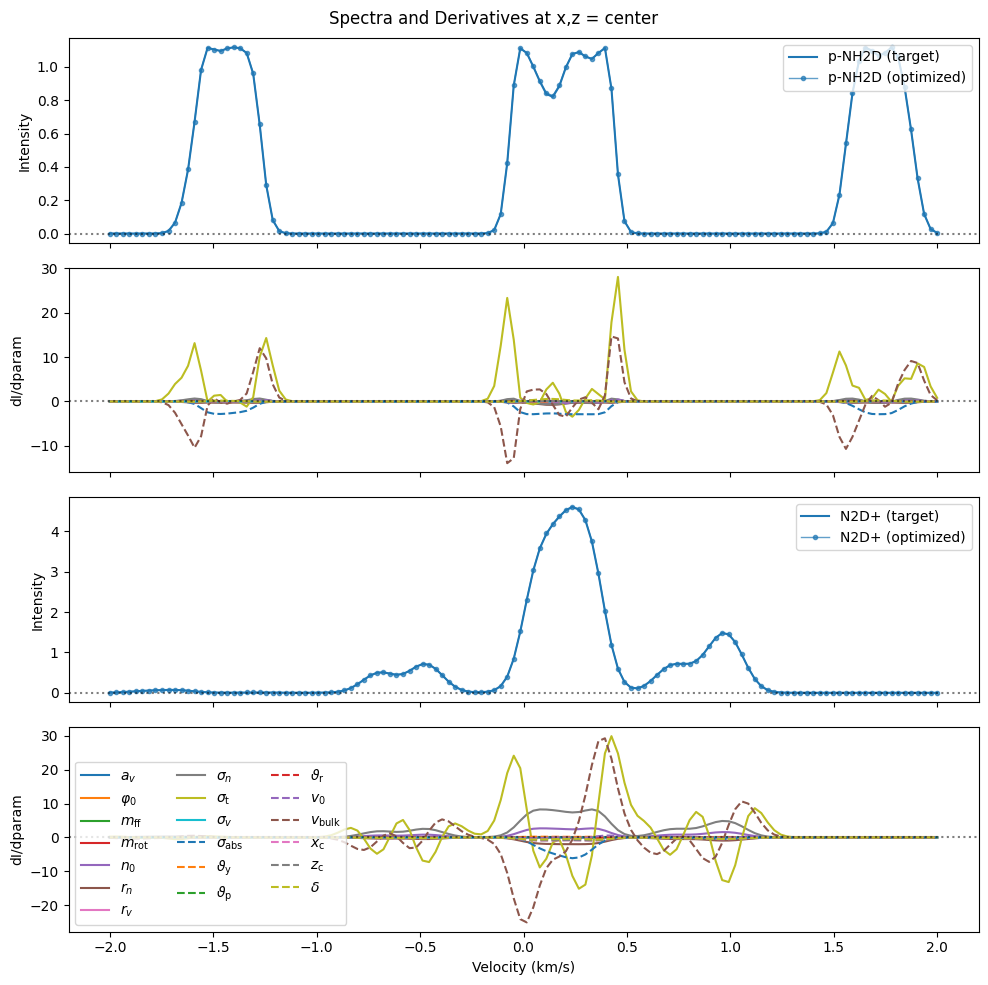

In [ ]:
fig, axs = plt.subplots(4, 1, figsize=(10, 10), sharex=True)

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
lss = ['-', '--', ':', '-.']

latex = {"asym": "$a_v$",
         "asym_theta": "$\\varphi_0$",
         "mff": "$m_{\\rm ff}$",
         "mrot": "$m_{\\rm rot}$",
         "ngas0": "$n_0$",
         "r0_ngas": "$r_n$",
         "r0_v": "$r_v$",
         "sigma_ngas": "$\\sigma_n$",
         "sigma_turb": "$\\sigma_{\\rm t}$",
         "sigma_v": "$\\sigma_v$",
         "sigmadx": "$\\sigma_{\\rm abs}$",
         "theta0": "$\\vartheta_{\\rm y}$",
         "theta1": "$\\vartheta_{\\rm p}$",
         "theta2": "$\\vartheta_{\\rm r}$",
         "v0": "$v_0$",
         "vbulk": "$v_{\\rm bulk}$",
         "xoffset": "$x_{\\rm c}$",
         "zoffset": "$z_{\\rm c}$",
         "zratio": "$\\delta$"
}

icount = 0
for param_name, param_value in tqdm(optimized_params.items()):
    dfdp = df_dparam(optimized_params, model_args, param_name, nmodels=2)
    #print(f"Derive wrt {param_name:16s} {np.abs(dfdp[0]).max():.6e}, {np.abs(dfdp[1]).max():.6e}")

    nmodels, nx, nz, _ = dfdp.shape
    for i in range(nmodels):
        ax = axs[i*2+1]
        ax.plot(vchans, dfdp[i, nx//2, nz//2, :], label=latex[param_name], color=colors[icount % len(colors)], ls=lss[icount // len(colors)])

    icount += 1

for i in range(nmodels):
    ax = axs[i*2]
    p = ax.plot(vchans, ppvs_target[i, nx//2, nz//2, :], label=f"{molecules[i]} (target)")
    ax.plot(vchans, ppvs_optimized[i, nx//2, nz//2, :], label=f"{molecules[i]} (optimized)", color=p[0].get_color(), lw=1, marker='.', alpha=0.7)
    ax.legend(loc='upper right')
    ax.set_ylabel("Intensity")

for ax in axs:
    ax.axhline(0., color='k', ls=':', alpha=0.5)

for i in [1, 3]:
    ax = axs[i]
    ax.set_ylabel("dI/dparam")

axs[3].legend(ncols=3, fontsize=10, loc='lower left')


axs[-1].set_xlabel("Velocity (km/s)")

#plt.legend()
plt.suptitle("Spectra and Derivatives at x,z = center")
plt.tight_layout()
plt.savefig("derivatives.pdf")
plt.show()

### Compare final parameter values with target and initial values

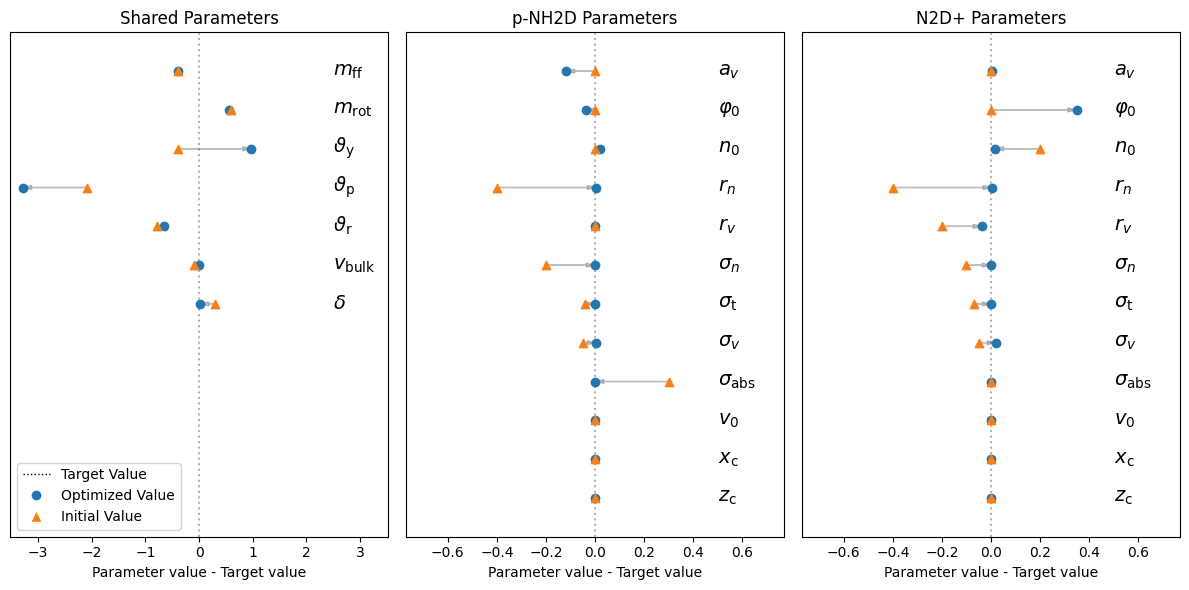

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(12, 6))

vmax = [3.2, 0.7, 0.7]
tpos = [2.5, 0.5, 0.5]
acount = np.zeros_like(axs)
for i in range(2):
    for k in sorted(optimized_params.keys()):
        ph = params_history[k]
        ph_target = target_params[k]
        ph_init = init_params[k]
        if type(ph[0]) != float:
            v = ph[-1][i]
            v_target = ph_target[i]
            v_init = ph_init[i]
            idx = i + 1
        else:
            if i >= 1:
                continue
            v = ph[-1]
            v_target = ph_target
            v_init = ph_init
            idx = 0

        lab = f"{latex[k]}"
        icount = -acount[idx]
        ax = axs[idx]
        acount[idx] += 1  # just to use idx variable

        ax.scatter([v - v_target], [icount], color="tab:blue")
        #plt.scatter([icount], [v_target], color="tab:orange", marker='x')
        ax.scatter([v_init - v_target], [icount], color="tab:orange", marker='^')
        ax.text(tpos[idx], icount, lab, rotation=0, va='center', ha='left', fontsize=14)

        dv = v - v_init
        if abs(dv) > vmax[idx]*0.05:
            ax.arrow(v_init - v_target, icount, dv, 0,
                    length_includes_head=True, head_width=0.1, head_length=vmax[idx]*0.05, fc='gray', ec='gray', alpha=0.5, zorder=-999)

for i, ax in enumerate(axs):
    ax.axvline(0.0, color='k', linestyle=':', alpha=0.3, zorder=-999)
    ax.set_yticks([])
    ax.set_xlabel("Parameter value - Target value")
    ax.set_xlim(-vmax[i]*1.1, vmax[i]*1.1)
    ax.set_ylim(-acount.max(), 1)

axs[0].legend([plt.Line2D([0], [0], color='k', lw=1, ls=':', label='Target Value'),
               plt.Line2D([0], [0], marker='o', color='w', label='Optimized Value', markerfacecolor='tab:blue', markersize=8),
               plt.Line2D([0], [0], marker='^', color='w', label='Initial Value', markerfacecolor='tab:orange', markersize=8)],
        ['Target Value', 'Optimized Value', 'Initial Value'], loc='lower left')

axs[0].set_title("Shared Parameters")
axs[1].set_title(f"{molecules[0]} Parameters")
axs[2].set_title(f"{molecules[1]} Parameters")

#plt.title("Optimized Parameters vs Target Parameters")
plt.tight_layout()
plt.savefig("optimized_parameters.pdf", bbox_inches='tight')
plt.show()

### Show parameter evolution during optimization

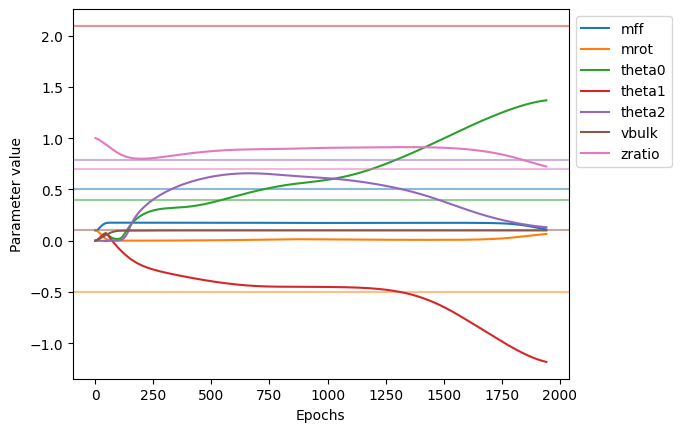

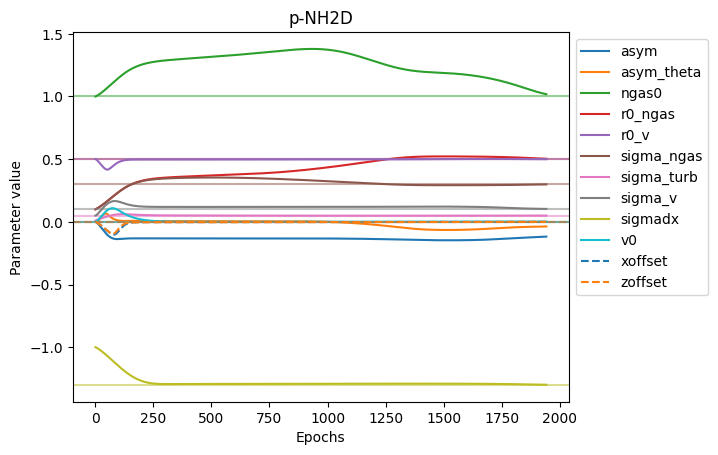

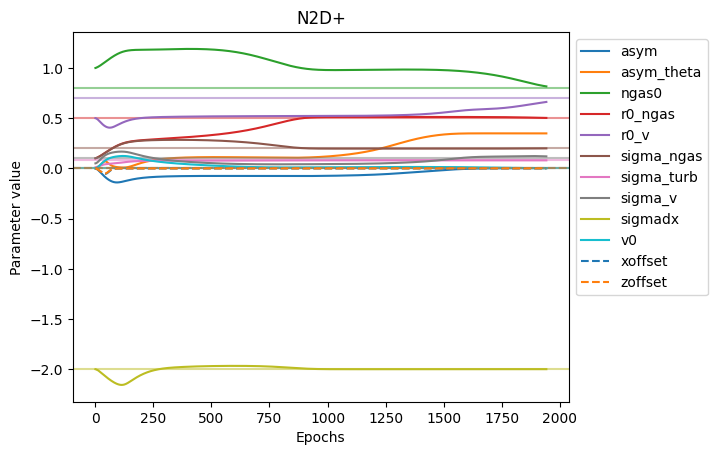

In [ ]:

for k, v in optimized_params.items():
    ph = params_history[k]
    if type(ph[0]) == float:
        p = plt.plot(ph, label=k)
        plt.axhline(target_params[k], color=p[0].get_color(), alpha=0.5)
plt.xlabel("Epochs")
plt.ylabel("Parameter value")
plt.legend(ncols=1, loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

# get color cycle from plt
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
lss = ['-', '--']

for i in range(2):
    icount = 0
    for k, v in optimized_params.items():
        ph = params_history[k]
        if type(ph[0]) != float:
            plt.plot([x[i] for x in ph], label=k, color=colors[icount % len(colors)], linestyle=lss[icount // len(colors)])
            plt.axhline(target_params[k][i], color=colors[icount % len(colors)], linestyle=lss[icount // len(colors)], alpha=0.5)
            icount += 1
    plt.legend(ncols=1, loc='upper left', bbox_to_anchor=(1, 1.))
    plt.xlabel("Epochs")
    plt.ylabel("Parameter value")
    plt.title(molecules[i])
    plt.show()